Now it's time to do the same process for fcov but for OC,CA but with 2024

In [1]:
# Import Libraries
import os
import earthaccess
import numpy as np
import geopandas as gpd
import pandas as pd
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
# QC flag codes -- from singleband_raster_hierarchy() in create_frcov_masks.py,
# https://github.com/emit-sds/emit-sds-frcov (not formally published in the User Guide).
# Hierarchical: each pixel gets the FIRST condition below that applies to it.
flag_labels = {
    0: "clear",
    1: "cloud_or_cirrus",
    2: "urban",
    3: "water_or_coastal",
    4: "snow_ice",
}  # -9999 = nodata (outside scene footprint); handled separately via masked=True on load

flag_colors = ["#2ca02c", "#7f7f7f", "#d62728", "#1f77b4", "#f2f2f2"]
cmap = ListedColormap(flag_colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

In [3]:
# Authenticate with NASA Earthdata (reads ~/.netrc, or prompts + persists on first run)
auth = earthaccess.login(persist=True)

In [4]:
# EMIT L2B Fractional Cover & Uncertainty (60 m, V001) over Maui.
# Currently narrowed to the exact acquisition date (2025-08-17) of the granule from
# https://search.earthdata.nasa.gov/...&g=G3991818701-LPCLOUD -- widen `temporal`
# (e.g. back to a month-long window) to search more broadly.
bbox = (-118.1909461519469, 33.427770107551254, -117.56889249781646, 33.91656441602717)  # (lon_min, lat_min, lon_max, lat_max) i.e., (West, South, East, North) in decimal degrees/boundaries
temporal = ("2024-01-31", "2024-12-31")  # (start_date, end_date) in YYYY-MM-DD format

results = earthaccess.search_data(
    concept_id="C3911089796-LPCLOUD",  # EMIT_L2BFRCOV.001 collection (LPCLOUD)
    bounding_box=bbox,
    temporal=temporal,
)

print(f"Found {len(results)} granule(s)")

Found 13 granule(s)


/Users/gillopez/miniforge3/envs/lpdaac_vitals/lib/python3.12/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [5]:
# Print every file (granule ID + all associated data/browse links) found in the search
for granule in results:
    print(granule["meta"]["native-id"])
    for link in granule.data_links():
        print(f"  {link}")

EMIT_L2B_FRCOV_001_20240322T231951_2408215_002
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20240322T231951_2408215_002/EMIT_L2B_FRCOVQC_001_20240322T231951_2408215_002.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20240322T231951_2408215_002/EMIT_L2B_FRCOVPV_001_20240322T231951_2408215_002.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20240322T231951_2408215_002/EMIT_L2B_FRCOVPVUNC_001_20240322T231951_2408215_002.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20240322T231951_2408215_002/EMIT_L2B_FRCOVNPV_001_20240322T231951_2408215_002.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/EMITL2BFRCOV.001/EMIT_L2B_FRCOV_001_20240322T231951_2408215_002/EMIT_L2B_FRCOVNPVUNC_001_20240322T231951_2408215_002.tif
  https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-p

## Step 2: Locally download granules of interest

For every granule the search above found, there are 7 GeoTIFFs to download. Load them into one
 `xarray.Dataset`, and apply the QC band as a mask across the fraction
(PV/NPV/BARE) and uncertainty bands.

In [6]:
def download_and_reconcile(granule):
    """Download a granule's 7 GeoTIFFs, load into one aligned Dataset, mask
    fraction + uncertainty bands to QC-clear pixels (qc == 0). Returns (ds, ds_clear).
    QC flag source: create_frcov_masks.py in github.com/emit-sds/emit-sds-frcov."""
    granule_id = granule["meta"]["native-id"]
    out_dir = os.path.join("data", "emit_fcov", granule_id)
    os.makedirs(out_dir, exist_ok=True)
    files = earthaccess.download([granule], local_path=out_dir)

    roles = {}
    for f in files:
        name = os.path.basename(f)
        if "FRCOVQC" in name:
            roles["qc"] = f
        elif "FRCOVPVUNC" in name:
            roles["pv_unc"] = f
        elif "FRCOVNPVUNC" in name:
            roles["npv_unc"] = f
        elif "FRCOVBAREUNC" in name:
            roles["bare_unc"] = f
        elif "FRCOVPV" in name:
            roles["pv"] = f
        elif "FRCOVNPV" in name:
            roles["npv"] = f
        elif "FRCOVBARE" in name:
            roles["bare"] = f
    assert len(roles) == 7, f"Expected 7 bands, matched {len(roles)}: {roles}"

    g_ds = xr.Dataset(
        {role: rxr.open_rasterio(path, masked=True).squeeze("band", drop=True)
         for role, path in roles.items()}
    )

    clear = g_ds["qc"] == 0  # only unflagged pixels are retrieval-valid per the ATBD mask hierarchy
    g_ds_clear = g_ds.copy()
    for v in ["pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]:
        g_ds_clear[v] = g_ds[v].where(clear)

    return g_ds, g_ds_clear

In [7]:
# Process every granule the search found (not just one hardcoded scene) so this
# notebook still works if you change the bbox/temporal window above.
granules = {}
for g in results:
    gid = g["meta"]["native-id"]
    print(f"Processing {gid} ...")
    g_ds, g_ds_clear = download_and_reconcile(g)
    granules[gid] = (g_ds, g_ds_clear)

    total = int(g_ds["qc"].notnull().sum())
    n_clear = int((g_ds["qc"] == 0).sum())
    print(f"  {n_clear}/{total} pixels clear ({100 * n_clear / total:.1f}%)")

print(f"\nReconciled {len(granules)} granule(s).")

Processing EMIT_L2B_FRCOV_001_20240322T231951_2408215_002 ...


/Users/gillopez/miniforge3/envs/lpdaac_vitals/lib/python3.12/site-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

...

/Users/gillopez/miniforge3/envs/lpdaac_vitals/lib/python3.12/site-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/7 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/7 [00:00<?, ?it/s]

  1705183/2207923 pixels clear (77.2%)

Reconciled 13 granule(s).


# Mosaic All Scenes

Merge every granule's QC-masked Dataset into one continuous mosaic. Works for any number
of granules (1..N) — if the search above returns a single scene the "mosaic" is just
that scene; if it returns several, they all get merged into one.

In [8]:
mosaic_vars = ["qc", "pv", "npv", "bare", "pv_unc", "npv_unc", "bare_unc"]

ds_mosaic = xr.Dataset({
    v: merge_arrays([g_ds_clear[v] for _, g_ds_clear in granules.values()], nodata=np.nan)
    for v in mosaic_vars
})

print(f"Mosaicked {len(granules)} scene(s) -> shape {ds_mosaic['pv'].shape}")

frac_sum = ds_mosaic["pv"] + ds_mosaic["npv"] + ds_mosaic["bare"]
print(f"Mosaic PV+NPV+BARE (clear pixels) -> mean: {float(frac_sum.mean(skipna=True)):.4f}, "
      f"std: {float(frac_sum.std(skipna=True)):.4f} (should be ~1.0 / ~0)")

Mosaicked 13 scene(s) -> shape (4344, 4964)
Mosaic PV+NPV+BARE (clear pixels) -> mean: 1.0000, std: 0.0000 (should be ~1.0 / ~0)


In [9]:
print(ds_mosaic.nbytes / 1e9, "GB")
print(ds_mosaic.dims)

1.121382504 GB
FrozenMappingWarningOnValuesAccess({'x': 4964, 'y': 4344})


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


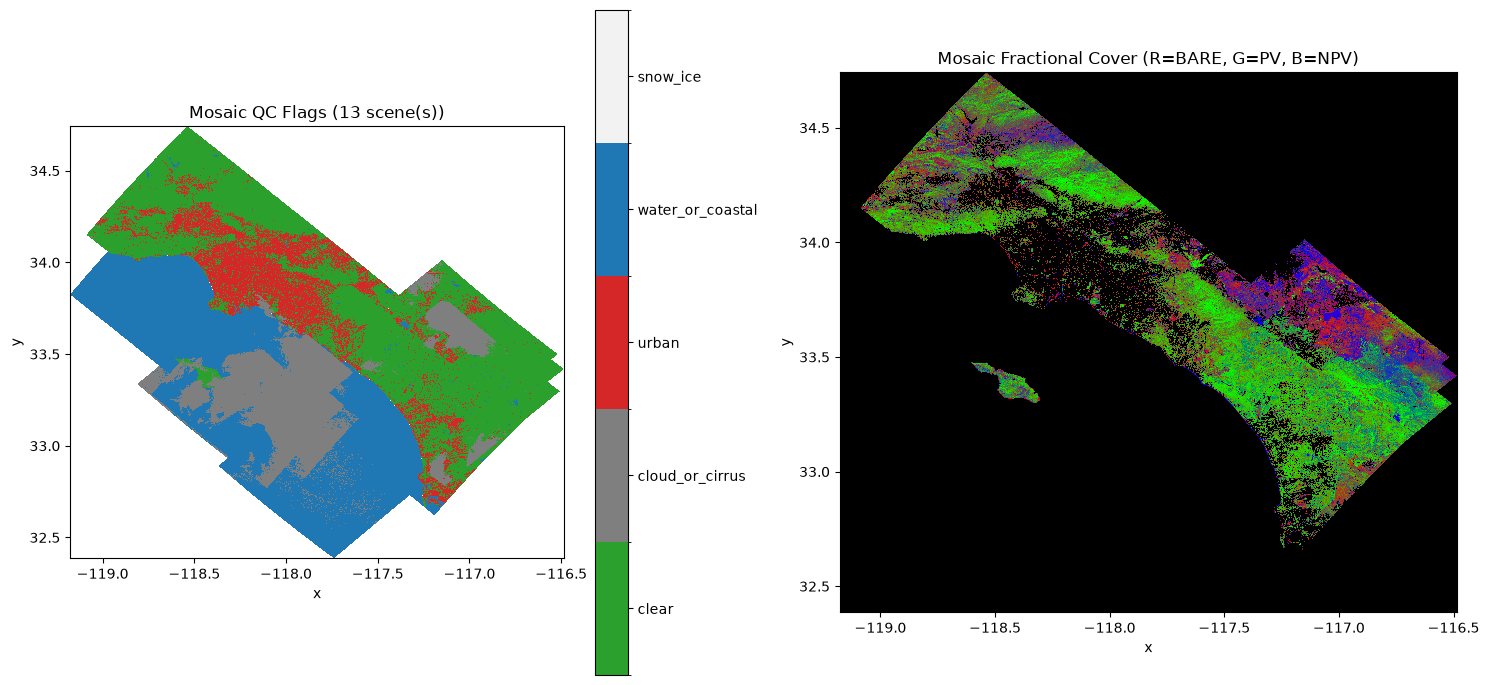

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

im0 = ds_mosaic["qc"].plot.imshow(ax=axes[0], cmap=cmap, norm=norm, add_colorbar=False)
axes[0].set_title(f"Mosaic QC Flags ({len(granules)} scene(s))")
axes[0].set_aspect("equal")
cbar = fig.colorbar(im0, ax=axes[0], ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(list(flag_labels.values()))

rgb_mosaic = xr.concat(
    [ds_mosaic["bare"].fillna(0), ds_mosaic["pv"].fillna(0), ds_mosaic["npv"].fillna(0)],
    dim="band",
).transpose("y", "x", "band")

rgb_mosaic.plot.imshow(ax=axes[1], rgb="band")
axes[1].set_title("Mosaic Fractional Cover (R=BARE, G=PV, B=NPV)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

 Export Mosaic (Analysis-Ready GeoTIFFs)

In [11]:
export_dir = os.path.join("data", "processed")
os.makedirs(export_dir, exist_ok=True)

for var in mosaic_vars:
    out_path = os.path.join(export_dir, f"emit_2025fcov_mosaic_{var}.tif")
    da = ds_mosaic[var]
    # qc is integer-dtype -- reuse its native -9999 nodata sentinel (see flag_labels
    # comment above) since NaN isn't representable in an int raster. Everything else
    # (fraction + uncertainty bands) is float, so NaN is fine.
    nodata = -9999 if var == "qc" else np.nan
    # Both attrs and encoding can carry a stale _FillValue (attrs from write_nodata()
    # below, encoding inherited from open_rasterio(masked=True) via merge_arrays) --
    # to_raster()'s CF encoder refuses to reconcile them itself, so clear both first.
    da.attrs.pop("_FillValue", None)
    da.encoding.pop("_FillValue", None)
    if var == "qc":
        da = da.fillna(nodata).astype("int16")
    da.rio.write_nodata(nodata, inplace=True)
    da.rio.to_raster(out_path, compress="LZW")
    print(f"Wrote {out_path}")

Wrote data/processed/emit_2025fcov_mosaic_qc.tif
Wrote data/processed/emit_2025fcov_mosaic_pv.tif
Wrote data/processed/emit_2025fcov_mosaic_npv.tif
Wrote data/processed/emit_2025fcov_mosaic_bare.tif
Wrote data/processed/emit_2025fcov_mosaic_pv_unc.tif
Wrote data/processed/emit_2025fcov_mosaic_npv_unc.tif
Wrote data/processed/emit_2025fcov_mosaic_bare_unc.tif


Preliminary Stats

In [12]:
stats_rows = []
for var in ["pv", "npv", "bare"]:
    data = ds_mosaic[var].compute()
    unc = ds_mosaic[f"{var}_unc"].compute()
    stats_rows.append({
        "band": var,
        "mean": float(data.mean(skipna=True)),
        "median": float(data.median(skipna=True)),
        "std": float(data.std(skipna=True)),
        "min": float(data.min(skipna=True)),
        "max": float(data.max(skipna=True)),
        "mean_uncertainty": float(unc.mean(skipna=True)),
    })

stats_df = pd.DataFrame(stats_rows).set_index("band")
print(stats_df.round(4))

        mean  median     std  min  max  mean_uncertainty
band                                                    
pv    0.4715  0.4870  0.2591  0.0  1.0            0.0433
npv   0.2194  0.1721  0.2082  0.0  1.0            0.1318
bare  0.3091  0.2956  0.1952  0.0  1.0            0.1286


In [13]:
# Dominant cover class per pixel (whichever of PV/NPV/BARE has the highest fraction there)
stacked = xr.concat(
    [ds_mosaic["pv"], ds_mosaic["npv"], ds_mosaic["bare"]], dim="band"
).assign_coords(band=["pv", "npv", "bare"])
dominant = stacked.idxmax(dim="band")

n_valid = int(dominant.notnull().sum())
print(f"\nDominant cover class ({n_valid} clear pixels):")
for label in ["pv", "npv", "bare"]:
    n = int((dominant == label).sum())
    print(f"  {label:5s}: {n:8d}  ({100 * n / n_valid:5.1f}%)")


Dominant cover class (4351992 clear pixels):
  pv   :  2499394  ( 57.4%)
  npv  :   654597  ( 15.0%)
  bare :  1198001  ( 27.5%)
